In [3]:
%load_ext rpy2.ipython

The rpy2.ipython extension is already loaded. To reload it, use:
  %reload_ext rpy2.ipython


In [4]:
%%R

#install.packages("tibble")
#install.packages("dplyr")
#install.packages(ggplot2)
#install.packages("caret")
#install.packages("glmnet")

library(tibble)
library(dplyr)
library(ggplot2)
library(caret)
library(pROC)
library(ROSE)
library(glmnet)

In [5]:
%%R
# Defining GMIDs for Red Routes
# Am creating a list of GMIDs for processing
green_route_gmIDs  <- c(
    "40706f50-f03b-11ee-b96e-fb353e7798cd",
"9df14b4e-f172-11ee-baa6-fb353e7798cd",
"88b0613a-d35d-11ee-b437-336917683bb8",
"7e3d64da-f12d-11ee-ba68-fb353e7798cd",
"fa9cba86-f0f0-11ee-ba2a-fb353e7798cd",
"7948628e-f20b-11ee-bb0f-fb353e7798cd",
"a231c0b0-f142-11ee-ba76-fb353e7798cd",
"a901fe40-f0fd-11ee-ba39-fb353e7798cd",
"99b9f446-f1b2-11ee-bad3-fb353e7798cd",
"c59a54e0-f179-11ee-baab-fb353e7798cd",
"25641404-cb66-11ee-909c-e1dc60cf66f9",
"14b6bc9c-f064-11ee-b998-fb353e7798cd",
"5c7a9ab2-f13b-11ee-ba72-fb353e7798cd",
"f8fd0fd8-f243-11ee-bb3f-fb353e7798cd",
"4c88757c-f157-11ee-ba89-fb353e7798cd",
"ba87f3ec-f07e-11ee-b9b4-fb353e7798cd",
"58d78342-f24a-11ee-bb45-fb353e7798cd",
"de493be2-f10f-11ee-ba4b-fb353e7798cd",
"848e44a6-f134-11ee-ba6d-fb353e7798cd",
"3d8020aa-cb7f-11ee-909c-e1dc60cf66f9",
"c4fca7bc-f18e-11ee-bab8-fb353e7798cd",
"c4146d46-f074-11ee-b9ac-fb353e7798cd",
"fe0395f0-f1ea-11ee-baf9-fb353e7798cd",
"271fee10-cb8b-11ee-909c-e1dc60cf66f9",
"5fc763f6-f1ab-11ee-bacd-fb353e7798cd",
"b3ee0dd8-f0d7-11ee-ba18-fb353e7798cd",
"a08a8c7e-f1fb-11ee-bb05-fb353e7798cd",
"7f824ea2-f05e-11ee-b993-fb353e7798cd",
"96ceec56-f1cf-11ee-bae4-fb353e7798cd",
"0f3cdf60-f1f6-11ee-bb00-fb353e7798cd",
"53fad09e-f0f7-11ee-ba2f-fb353e7798cd",
"f570c51c-f15d-11ee-ba91-fb353e7798cd",
"cbdc93f4-f255-11ee-bb4e-fb353e7798cd",
"d7cb9c92-f164-11ee-ba97-fb353e7798cd",
"7a22a34c-f1f0-11ee-bafe-fb353e7798cd",
"d454c586-f11c-11ee-ba55-fb353e7798cd",
"837fc882-cb5a-11ee-909c-e1dc60cf66f9",
"8e5c4fc2-f149-11ee-ba7f-fb353e7798cd",
"c2f54552-f06f-11ee-b9a9-fb353e7798cd",
"43abeb00-f206-11ee-bb07-fb353e7798cd",
"25135418-f250-11ee-bb4a-fb353e7798cd",
"f9c5e53e-f0ea-11ee-ba28-fb353e7798cd",
"4cf81634-f238-11ee-bb34-fb353e7798cd",
"d846a080-f115-11ee-ba51-fb353e7798cd",
"1c74d294-f1e4-11ee-baf0-fb353e7798cd",
"3c415ade-d353-11ee-b437-336917683bb8",
"8adb6498-f04d-11ee-b981-fb353e7798cd",
"de226278-f25a-11ee-bb4e-fb353e7798cd",
"c14299be-f180-11ee-bab0-fb353e7798cd",
"870cfd32-f1b9-11ee-bad5-fb353e7798cd",
"3ed4aa16-f1d6-11ee-bae6-fb353e7798cd",
"df6c3fb4-f200-11ee-bb07-fb353e7798cd",
"5f7ce340-f1c8-11ee-bae0-fb353e7798cd",
"b31aca98-cb95-11ee-909c-e1dc60cf66f9",
"f12112ba-f1c0-11ee-bada-fb353e7798cd",
"73bc30cc-f150-11ee-ba84-fb353e7798cd",
"3a7dc9a6-f042-11ee-b974-fb353e7798cd",
"dea29156-f123-11ee-ba5d-fb353e7798cd",
"044d976e-f0e5-11ee-ba20-fb353e7798cd",
"961fd9cc-f103-11ee-ba3f-fb353e7798cd",
"bbbd0cc6-f0dc-11ee-ba1e-fb353e7798cd",
"9736e77c-f187-11ee-bab6-fb353e7798cd",
"5774dcde-f196-11ee-babe-fb353e7798cd",
"ece2a8be-f047-11ee-b97d-fb353e7798cd",
"3ec95686-f053-11ee-b988-fb353e7798cd",
"51b74168-f19d-11ee-babf-fb353e7798cd",
"bb4d37d4-f109-11ee-ba46-fb353e7798cd",
"cf7148d8-f058-11ee-b98a-fb353e7798cd",
"bf9157f0-f16b-11ee-ba9e-fb353e7798cd",
"98692fde-f1a4-11ee-bac6-fb353e7798cd",
"25e27b86-f06a-11ee-b9a3-fb353e7798cd",
"a6539bd2-cb72-11ee-909c-e1dc60cf66f9",
"5afabc8c-f035-11ee-b966-fb353e7798cd",
"c1b320e2-f079-11ee-b9b0-fb353e7798cd",
"d1a3a310-f091-11ee-b9ce-fb353e7798cd",
"e9a1d768-f23d-11ee-bb39-fb353e7798cd",
"c9be2042-f0de-11ee-ba1e-fb353e7798cd",
"ed352100-cba0-11ee-909c-e1dc60cf66f9",
"8b0593cc-cb4e-11ee-909c-e1dc60cf66f9",
"236836f6-f1dd-11ee-bae8-fb353e7798cd",
"072ef896-cbac-11ee-909c-e1dc60cf66f9"
)

In [6]:
%%R
# Define the base directory for preprocessed data
base_path <- "/home/gampadu_linux/Desktop/TDMprivate/Preprocessed_Moving_Data_v2/2sec_moving_window"

# List all files in the directory
all_files <- list.files(base_path, full.names = FALSE)

# Extract gmIDs from filenames (remove ".csv" extension)
existing_gmIDs <- sub("\\.csv$", "", all_files)

# Find gmIDs that exist in the directory
matching_gmIDs <- intersect(green_route_gmIDs, existing_gmIDs)

# Find gmIDs that are missing
missing_gmIDs <- setdiff(green_route_gmIDs, existing_gmIDs)

# Display results
print(paste("Total files found:", length(existing_gmIDs)))
print(paste("Matching gmIDs:", length(matching_gmIDs)))
print(paste("Missing gmIDs:", length(missing_gmIDs)))

# Display first 10 missing gmIDs
print("Missing gmIDs (first 10):")
print(head(missing_gmIDs, 10))

[1] "Total files found: 247"
[1] "Matching gmIDs: 81"
[1] "Missing gmIDs: 0"
[1] "Missing gmIDs (first 10):"
character(0)


In [7]:
%%R

# Check if a specific file exists
print(file.exists(file.path(base_path, existing_gmIDs[1])))

# List files inside a GMID folder
print(list.files(file.path(base_path, existing_gmIDs[1]), full.names = TRUE))

[1] TRUE
[1] "/home/gampadu_linux/Desktop/TDMprivate/Preprocessed_Moving_Data_v2/2sec_moving_window/01e65360-efd4-11ee-b966-fb353e7798cd/01e65360-efd4-11ee-b966-fb353e7798cd.csv"


In [8]:
%%R
# Read first available CSV file
file_path <- list.files(file.path(base_path, matching_gmIDs[1]), pattern = "\\.csv$", full.names = TRUE)
temp_data <- read.csv(file_path[1])

# Display column names
print(names(temp_data))

 [1] "Ind"                         "groupMetadataID"            
 [3] "time"                        "NormalizedTime"             
 [5] "BinaryDrivingMode"           "BinaryDisengagement"        
 [7] "BinaryDisengagementExpanded" "DisengagementID"            
 [9] "DisengagementExpandedID"     "latitude"                   
[11] "longitude"                   "ProgressAlongRoute"         
[13] "solStatus"                   "solType"                    
[15] "extendedSolutionStatus"      "numSatsInSolution"          
[17] "speedMps_mean"               "Acceleration_mean"          
[19] "brakePercentage_mean"        "throttlePercentage_mean"    
[21] "steeringPercentage_mean"     "LatLonTotalStdDev_mean"     


In [9]:
%%R
valid_files <- c()  # Store GMIDs that contain the required columns

for (id in matching_gmIDs) {
    file_path <- list.files(file.path(base_path, id), pattern = "\\.csv$", full.names = TRUE)
    
    if (length(file_path) > 0) {  # Ensure at least one file exists
        temp_data <- read.csv(file_path[1])  # Read first file
        
        # Check if required column exists
        if ("LatLonTotalStdDev_mean" %in% names(temp_data)) {
            valid_files <- c(valid_files, id)
        }
    }
}

# Print results
print(paste("Number of GMIDs that contain required columns:", length(valid_files)))

[1] "Number of GMIDs that contain required columns: 81"


In [10]:
%%R
# Initialize an empty tibble to store merged data
df_merged <- tibble()

# Loop through only valid GMIDs and read CSV files
for (id in valid_files) {
    file_path <- list.files(file.path(base_path, id), pattern = "\\.csv$", full.names = TRUE)
    
    if (length(file_path) > 0) {
        temp_data <- read.csv(file_path[1])  # Read first CSV file
        
        # Append to merged dataset
        df_merged <- bind_rows(df_merged, temp_data)
    }
}

In [11]:
%%R
# Check for missing data
colSums(is.na(df_merged))

# Check class balance for BinaryDisengagementExpanded
table(df_merged$BinaryDisengagementExpanded)


      0       1 
2165147   12246 


In [12]:
%%R
# Load required library
library(dplyr)

# Define training and testing GMIDs based on red_route_gmIDs
training_gmIDs <- green_route_gmIDs[1:92]  # First 92 GMIDs for training
testing_gmIDs <- green_route_gmIDs[(length(green_route_gmIDs)-4):length(green_route_gmIDs)]  # Last 5 GMIDs for testing

# Filter df_merged for training and testing data based on GMIDs
train_data <- df_merged %>% filter(groupMetadataID %in% training_gmIDs)
test_data <- df_merged %>% filter(groupMetadataID %in% testing_gmIDs)

# Check the number of rows in each dataset
print(paste("Training data rows:", nrow(train_data)))
print(paste("Testing data rows:", nrow(test_data)))

# Verify if test_data is empty
if (nrow(test_data) == 0) {
    print("Error: test_data is empty. Check GMID filtering.")
}

[1] "Training data rows: 2177393"
[1] "Testing data rows: 186378"


In [13]:
%%R
# Train a Logistic Regression Model using BinaryDisengagementExpanded
model <- glm(
  BinaryDisengagementExpanded ~ speedMps_mean + throttlePercentage_mean + brakePercentage_mean + steeringPercentage_mean + LatLonTotalStdDev_mean,
  data = train_data,
  family = binomial
)

# Display model summary
summary(model)


Call:
glm(formula = BinaryDisengagementExpanded ~ speedMps_mean + throttlePercentage_mean + 
    brakePercentage_mean + steeringPercentage_mean + LatLonTotalStdDev_mean, 
    family = binomial, data = train_data)

Deviance Residuals: 
    Min       1Q   Median       3Q      Max  
-0.7167  -0.1090  -0.0828  -0.0675   3.6099  

Coefficients:
                          Estimate Std. Error  z value Pr(>|z|)    
(Intercept)             -4.4306451  0.0224512 -197.346   <2e-16 ***
speedMps_mean           -0.0880977  0.0013955  -63.132   <2e-16 ***
throttlePercentage_mean  0.0096682  0.0008351   11.577   <2e-16 ***
brakePercentage_mean     0.0302385  0.0004963   60.931   <2e-16 ***
steeringPercentage_mean  0.0049737  0.0005544    8.972   <2e-16 ***
LatLonTotalStdDev_mean   0.1450463  0.0075231   19.280   <2e-16 ***
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

(Dispersion parameter for binomial family taken to be 1)

    Null deviance: 151308  on 2177392  degrees of freed

In [14]:
%%R
# Predict on the test set
predictions <- predict(model, test_data, type = "response")

# Convert probabilities to binary classes (0 or 1)
predicted_classes <- ifelse(predictions > 0.5, 1, 0)

# Calculate accuracy
accuracy <- mean(predicted_classes == test_data$BinaryDisengagementExpanded)

# Print the accuracy
print(paste("Accuracy:", accuracy))

[1] "Accuracy: 0.995090622283746"


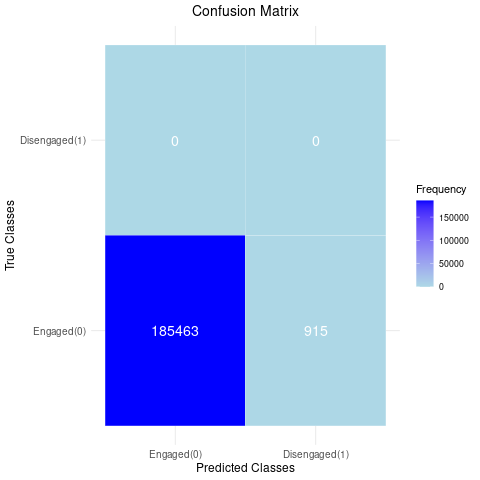

In [15]:
%%R
# Load required libraries
library(ggplot2)
library(caret)

# Map the values to labels (1 -> "Disengaged", 0 -> "Engaged")
predicted_classes_labeled <- factor(predicted_classes, levels = c(0,1), labels = c("Engaged(0)", "Disengaged(1)"))
actual_classes_labeled <- factor(test_data$BinaryDisengagementExpanded, levels = c(0,1), labels = c("Engaged(0)", "Disengaged(1)"))

# Generate the confusion matrix
cm <- confusionMatrix(predicted_classes_labeled, actual_classes_labeled)
cm_table <- as.data.frame(cm$table)

# Rename columns for better understanding
colnames(cm_table) <- c("Actual", "Predicted", "Frequency")

# Create the colored confusion matrix plot
ggplot(cm_table, aes(x = Predicted, y = Actual, fill = Frequency)) +
  geom_tile(color = "white") +
  scale_fill_gradient(low = "lightblue", high = "blue", name = "Frequency") +
  geom_text(aes(label = Frequency), color = "white", size = 5) +
  labs(title = "Confusion Matrix", x = "Predicted Classes", y = "True Classes") +
  theme_minimal() +
  theme(plot.title = element_text(hjust = 0.5, size = 14),
        axis.title = element_text(size = 12),
        axis.text = element_text(size = 10))

In [16]:
%%R
table(train_data$BinaryDisengagementExpanded)
table(test_data$BinaryDisengagementExpanded)


     0      1 
185463    915 


In [17]:
%%R
library(caret)

# Convert the response variable to a factor
train_data$BinaryDisengagementExpanded <- as.factor(train_data$BinaryDisengagementExpanded)

# Downsample the majority class (0s) to match the minority class (1s)
set.seed(42)
train_data_balanced <- downSample(
  x = train_data[, c("speedMps_mean", "throttlePercentage_mean", "brakePercentage_mean", "steeringPercentage_mean", "LatLonTotalStdDev_mean")], 
  y = train_data$BinaryDisengagementExpanded
)

# Check new distribution
table(train_data_balanced$Class)  # Should be balanced now


    0     1 
12246 12246 


In [18]:
%%R
# Rename 'Class' back to 'BinaryDisengagementExpanded'
train_data_balanced$BinaryDisengagementExpanded <- train_data_balanced$Class
train_data_balanced$Class <- NULL  # Optionally remove the 'Class' column

# Now you can train your model
model <- glm(
  BinaryDisengagementExpanded ~ speedMps_mean + throttlePercentage_mean + 
    brakePercentage_mean + steeringPercentage_mean + LatLonTotalStdDev_mean,
  data = train_data_balanced,
  family = binomial
)

summary(model)


Call:
glm(formula = BinaryDisengagementExpanded ~ speedMps_mean + throttlePercentage_mean + 
    brakePercentage_mean + steeringPercentage_mean + LatLonTotalStdDev_mean, 
    family = binomial, data = train_data_balanced)

Deviance Residuals: 
    Min       1Q   Median       3Q      Max  
-3.5355  -0.9366  -0.2347   1.0297   1.7648  

Coefficients:
                          Estimate Std. Error z value Pr(>|z|)    
(Intercept)              0.3950972  0.0445549   8.868  < 2e-16 ***
speedMps_mean           -0.0725146  0.0024137 -30.043  < 2e-16 ***
throttlePercentage_mean  0.0070117  0.0011725   5.980 2.23e-09 ***
brakePercentage_mean     0.0380481  0.0012206  31.172  < 2e-16 ***
steeringPercentage_mean -0.0004605  0.0011702  -0.394    0.694    
LatLonTotalStdDev_mean   0.4254820  0.0196864  21.613  < 2e-16 ***
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

(Dispersion parameter for binomial family taken to be 1)

    Null deviance: 33953  on 24491  degrees of freedo

In [19]:
%%R
# Predict on the test set using the trained model
predictions <- predict(model, test_data, type = "response")

# Convert probabilities to binary classes (0 or 1)
predicted_classes <- ifelse(predictions > 0.5, 1, 0)

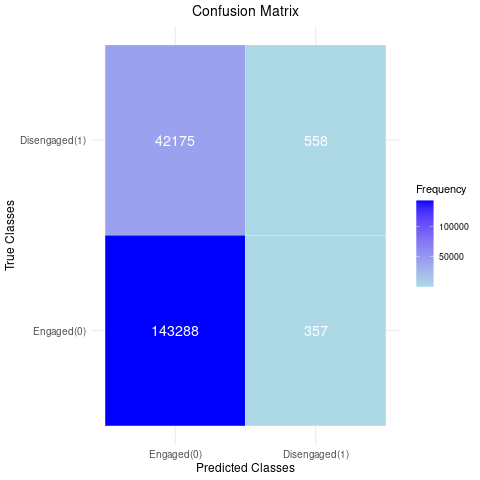

In [20]:
%%R
# Load required libraries
library(ggplot2)
library(caret)

# Convert actual and predicted values into factors for labeling
predicted_classes_labeled <- factor(predicted_classes, levels = c(0,1), labels = c("Engaged(0)", "Disengaged(1)"))
actual_classes_labeled <- factor(test_data$BinaryDisengagementExpanded, levels = c(0,1), labels = c("Engaged(0)", "Disengaged(1)"))

# Generate the confusion matrix
cm <- confusionMatrix(predicted_classes_labeled, actual_classes_labeled)
cm_table <- as.data.frame(cm$table)  # Convert to dataframe for visualization

# Rename columns for clarity
colnames(cm_table) <- c("Actual", "Predicted", "Frequency")

# Create the colored confusion matrix plot
ggplot(cm_table, aes(x = Predicted, y = Actual, fill = Frequency)) +
  geom_tile(color = "white") +
  scale_fill_gradient(low = "lightblue", high = "blue", name = "Frequency") +
  geom_text(aes(label = Frequency), color = "white", size = 5) +
  labs(title = "Confusion Matrix", x = "Predicted Classes", y = "True Classes") +
  theme_minimal() +
  theme(
    plot.title = element_text(hjust = 0.5, size = 14),
    axis.title = element_text(size = 12),
    axis.text = element_text(size = 10)
  )

In [21]:
%%R
# Manually calculating the confusion matrix values
TP <- 558  # True Positives
FP <- 357     # False Positives
FN <- 42175  # False Negatives
TN <- 143288    # True Negatives

# Calculate Metrics
accuracy <- (TP + TN) / (TP + TN + FP + FN)  # Overall correctness
precision <- TP / (TP + FP)                  # Precision (Positive Predictive Value)
recall <- TP / (TP + FN)                     # Recall (Sensitivity)
f1_score <- 2 * ((precision * recall) / (precision + recall))  # F1-score

# Print Metrics
cat("Accuracy:", round(accuracy, 4), "\n")  
cat("Precision:", round(precision, 4), "\n")  
cat("Recall:", round(recall, 4), "\n")  
cat("F1-score:", round(f1_score, 4), "\n")  

Accuracy: 0.7759 
Precision: 0.2209 
Recall: 0.0056 
F1-score: 0.0109 


In [22]:
%%R
# Filter actual disengagement locations (Ground Truth)
actual_disengaged <- test_data[test_data$BinaryDisengagementExpanded == 1, ]

# Extract actual disengagement coordinates
actual_latitudes <- actual_disengaged$latitude
actual_longitudes <- actual_disengaged$longitude

# Filter test data where the model predicted Disengagement (1)
predicted_disengaged <- test_data[predicted_classes == 1, ]

# Extract predicted disengagement coordinates
predicted_latitudes <- predicted_disengaged$latitude
predicted_longitudes <- predicted_disengaged$longitude

# Ensure both actual and predicted lists have the same length
min_length <- min(length(actual_latitudes), length(predicted_latitudes))
actual_latitudes <- actual_latitudes[1:min_length]
actual_longitudes <- actual_longitudes[1:min_length]
predicted_latitudes <- predicted_latitudes[1:min_length]
predicted_longitudes <- predicted_longitudes[1:min_length]

# Create a data frame with actual and predicted disengagement locations
disengagement_comparison <- data.frame(
    actual_latitude = actual_latitudes,
    actual_longitude = actual_longitudes,
    predicted_latitude = predicted_latitudes,
    predicted_longitude = predicted_longitudes
)

# Display first few rows to verify
head(disengagement_comparison)

  actual_latitude actual_longitude predicted_latitude predicted_longitude
1        39.31998        -82.42894           39.32677           -82.43896
2        39.31998        -82.42894           39.32677           -82.43896
3        39.31998        -82.42894           39.32677           -82.43896
4        39.31998        -82.42894           39.32677           -82.43896
5        39.31998        -82.42894           39.32677           -82.43896
6        39.31998        -82.42894           39.32677           -82.43896


In [23]:
%%R
head(disengagement_comparison)
dim(disengagement_comparison)

[1] 915   4


In [24]:
import rpy2.robjects as ro
from rpy2.robjects import pandas2ri
import pandas as pd

# Activate the conversion between R and pandas
pandas2ri.activate()

# Convert R dataframe to Pandas dataframe
disengagement_comparison_py = ro.conversion.rpy2py(ro.r('disengagement_comparison'))

# Verify if it's a Pandas DataFrame now
print(type(disengagement_comparison_py))  # Should output <class 'pandas.core.frame.DataFrame'>
print(disengagement_comparison_py.shape)  # Check shape
print(disengagement_comparison_py.head()) # Check first few rows

<class 'pandas.core.frame.DataFrame'>
(915, 4)
   actual_latitude  actual_longitude  predicted_latitude  predicted_longitude
1        39.319979        -82.428942           39.326768           -82.438955
2        39.319979        -82.428942           39.326768           -82.438955
3        39.319979        -82.428942           39.326768           -82.438955
4        39.319979        -82.428942           39.326768           -82.438955
5        39.319979        -82.428942           39.326768           -82.438955


(915, 4)


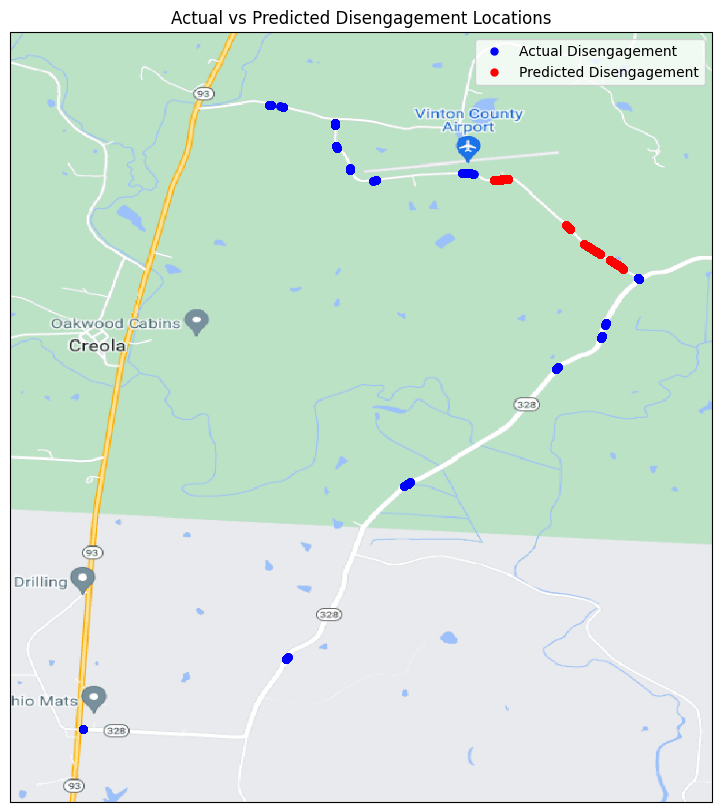

In [25]:
import cartopy.crs as ccrs
from cartopy.io.img_tiles import GoogleTiles
import matplotlib.pyplot as plt

# Define the dataframe for clarity
df = disengagement_comparison_py  

# Print shape for verification
print(df.shape)

# Define plot size
plt.figure(figsize=(10, 10))

# Get min and max latitude and longitude
minLat = df['actual_latitude'].min()
maxLat = df['actual_latitude'].max()
minLon = df['actual_longitude'].min()
maxLon = df['actual_longitude'].max()

# Define expansion coefficient to avoid edge cutoff
expansion_coeff = 0.005

# Load street map
street_map = GoogleTiles(style='street')

# Create plot with the street map
ax = plt.axes(projection=ccrs.PlateCarree())
ax.set_extent(
    [minLon - expansion_coeff, maxLon + expansion_coeff, 
     minLat - expansion_coeff, maxLat + expansion_coeff],
    crs=ccrs.PlateCarree()
)

# Add map image
ax.add_image(street_map, 14)

# Extract actual and predicted disengagement locations
true_disengage_lat = df['actual_latitude']
true_disengage_lon = df['actual_longitude']

pred_disengage_lat = df['predicted_latitude']
pred_disengage_lon = df['predicted_longitude']

# Plot actual disengagement locations (Blue)
plt.plot(true_disengage_lon, true_disengage_lat,
         marker='o', ls='', color='blue', ms=5, label='Actual Disengagement', 
         transform=ccrs.PlateCarree())

# Plot predicted disengagement locations (Red)
plt.plot(pred_disengage_lon, pred_disengage_lat,
         marker='o', ls='', color='red', ms=5, label='Predicted Disengagement', 
         transform=ccrs.PlateCarree())

# Add title and legend
plt.title('Actual vs Predicted Disengagement Locations')
plt.legend()

# Show the plot
plt.show()